# Neural Network from Scratch

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
np.random.seed(42)

## Downloading the dataset

In [3]:
import kagglehub

path = kagglehub.competition_download("digit-recognizer")
print(path)

100%|██████████| 15.3M/15.3M [00:00<00:00, 107MB/s] 

Extracting files...


/root/.cache/kagglehub/competitions/digit-recognizer


## Creating training and validation set

In [4]:
train_data = pd.read_csv("/root/.cache/kagglehub/competitions/digit-recognizer/train.csv")
train_data = np.array(train_data)
np.random.shuffle(train_data)

split = int(0.95 * train_data.shape[0])
train_data_split = train_data[:split]
valid_data = train_data[split:]

train_set = train_data_split.T
X_train = train_set[1:] / 255
Y_train = train_set[0]

valid_set = valid_data.T
X_valid = valid_set[1:] / 255
Y_valid = valid_set[0]

In [5]:
print(X_train.shape)
print(Y_train.shape)

print(X_valid.shape)
print(Y_valid.shape)

(784, 39900)
(39900,)
(784, 2100)
(2100,)


## Creating test set

In [6]:
test_data = pd.read_csv("/root/.cache/kagglehub/competitions/digit-recognizer/test.csv")
test_data = np.array(test_data)
X_test = test_data.T / 255

In [7]:
print(X_test.shape)

(784, 28000)


## Initializing parameters

In [8]:
def init_parameters(input_shape, output_shape, hidden_neurons):

  W1 = np.random.randn(hidden_neurons, input_shape) * np.sqrt(2. / input_shape)
  b1 = np.zeros((hidden_neurons, 1))

  W2 = np.random.randn(output_shape, hidden_neurons) * np.sqrt(2. / hidden_neurons)
  b2 = np.zeros((output_shape, 1))

  return W1, b1, W2, b2

## Helper functions

In [9]:
def ReLU(Z):
  return np.maximum(0, Z)

def d_ReLU(Z):
  return Z > 0

def Softmax(Z):
  return np.exp(Z) / sum(np.exp(Z))

def Onehot(Y):
  onehot = np.zeros((Y.size, Y.max() + 1))
  onehot[np.arange(Y.size), Y] = 1
  onehot = onehot.T
  return onehot

## Forward pass

In [10]:
def forward(W1, b1, W2, b2, X):

  Z1 = W1.dot(X) + b1
  A1 = ReLU(Z1)

  Z2 = W2.dot(A1) + b2
  A2 = Softmax(Z2)

  return Z1, A1, Z2, A2

## Backpropagation

In [11]:
def backpropagation(Z1, A1, Z2, A2, W1, W2, X, Y):

  m = X.shape[1]
  onehot = Onehot(Y)

  dZ2 = A2 - onehot
  dW2 = (1 / m) * dZ2.dot(A1.T)
  db2 = (1 / m) * np.sum(dZ2, axis = 1, keepdims = True)

  dZ1 = W2.T.dot(dZ2) * d_ReLU(Z1)
  dW1 = (1 / m) * dZ1.dot(X.T)
  db1 = (1 / m) * np.sum(dZ1, axis = 1, keepdims = True)

  return dW1, db1, dW2, db2

## Gradient Descent

In [12]:
def gradient_descent(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):

  W1 = W1 - (lr * dW1)
  b1 = b1 - (lr * db1)

  W2 = W2 - (lr * dW2)
  b2 = b2 - (lr * db2)

  return W1, b1, W2, b2

## Helper functions

In [13]:
def argmax_predictions(A2):
  return np.argmax(A2, 0)

def accuracy(predictions, ground_truth):
  return np.sum(predictions == ground_truth) / ground_truth.size

def predict(W1, b1, W2, b2, X):
  _, _, _, A2 = forward(W1, b1, W2, b2, X)
  predicted = argmax_predictions(A2)
  return predicted

## Train Function

In [14]:
def train(X, Y, X_valid, Y_valid, lr, epochs):

  W1, b1, W2, b2 = init_parameters(input_shape = X.shape[0], output_shape = 10, hidden_neurons = 128)

  pbar = tqdm(range(epochs), desc = f"Training: ", unit = "epoch")

  for epoch in pbar:

    Z1, A1, Z2, A2 = forward(W1, b1, W2, b2, X)
    dW1, db1, dW2, db2 = backpropagation(Z1, A1, Z2, A2, W1, W2, X, Y)
    W1, b1, W2, b2 = gradient_descent(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

    train_predicted = argmax_predictions(A2)
    train_accuracy = accuracy(train_predicted, Y)

    valid_predicted = predict(W1, b1, W2, b2, X_valid)
    valid_accuracy = accuracy(valid_predicted, Y_valid)

    pbar.set_postfix(train_accuracy = f"{train_accuracy:.4f}",valid_accuracy = f"{valid_accuracy:.4f}")

  return W1, b1, W2, b2

## Training the model

In [15]:
W1, b1, W2, b2 = train(
    X_train,
    Y_train,
    X_valid,
    Y_valid,
    lr = 0.5,
    epochs = 1000
)

Training: 100%|██████████| 1000/1000 [08:49<00:00,  1.89epoch/s, train_accuracy=0.9822, valid_accuracy=0.9776]


## Accucary of model

In [16]:
valid_predicted = predict(W1, b1, W2, b2, X_valid)
valid_accuracy = accuracy(valid_predicted, Y_valid)

print(f"Validation Accuracy: {valid_accuracy * 100:.2f}%")

Validation Accuracy: 97.76%


## Visualizing test results

In [17]:
def visualize_prediction(W1, b1, W2, b2, index):

  sample = X_train[:, index, None]
  prediction = predict(W1, b1, W2, b2, sample)
  label = Y_train[index]

  print("Prediction: ", prediction)
  print("Ground Truth: ", label)

  image = sample.reshape((28, 28)) * 255
  plt.gray()
  plt.imshow(image, interpolation = "nearest")
  plt.show()

Prediction:  [2]
Ground Truth:  2


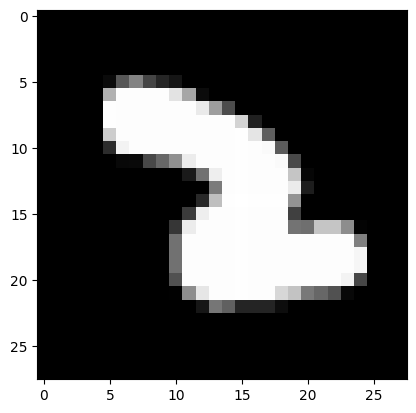

Prediction:  [2]
Ground Truth:  2


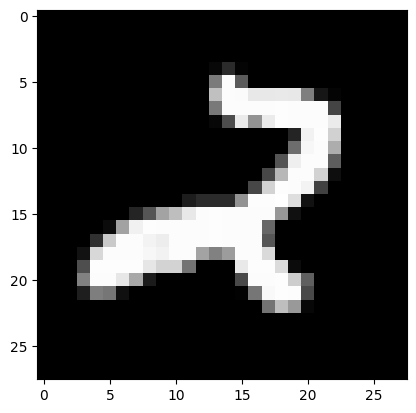

Prediction:  [8]
Ground Truth:  8


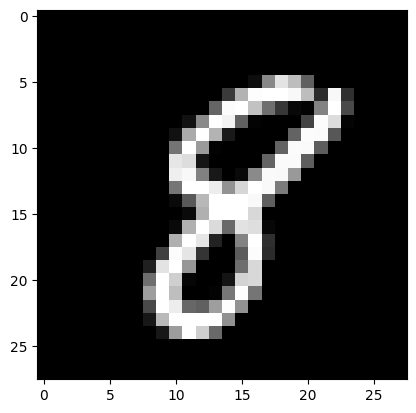

In [23]:
visualize_prediction(W1, b1, W2, b2, np.random.randint(1, 10))
visualize_prediction(W1, b1, W2, b2, np.random.randint(1, 10))
visualize_prediction(W1, b1, W2, b2, np.random.randint(1, 10))

In [19]:
test_predictions = predict(W1, b1, W2, b2, X_test)
print(test_predictions[:20])

[2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]


## Kaggle Submission

In [20]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_predictions) + 1),
    "Label": test_predictions
})

submission.to_csv("submission.csv", index = False)
print(submission.head())

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
